# Model comparison and robustness checks
### Supplementary analyses for *Framing Spatial Hearing within the Free Energy Principle* (IWAI 2026)

This notebook reproduces **Table 1** and **Appendix A.3** of the paper, i.e. the two analyses requested during review:

1. **Held-out model comparison** — are all three learning rates $(\eta_P, \eta_w, \eta_L)$ needed? Reduced models with $\eta_P = 0$ (polar precision frozen) and $\eta_w = 0$ (hemifield weight frozen) are compared with the full model on held-out trials.
2. **Robustness of the flat-$\kappa_P$ result** — does the conclusion depend on the $\cos^2(\alpha)$ scaling of polar precision, and how uncertain is $\eta_P$? The full model is refitted with the scaling removed, and a parametric bootstrap gives confidence intervals on $\eta_P$.

The model code (likelihood, natural-gradient update, data loading, baseline fit, BADS set-up) is identical to `MAIN_fep_simulation.ipynb`, which also states the model equations; the only additions are a trial mask for the likelihood sum, a `cos2_scaling` switch, and a multi-start BADS. Only the Manual-pointing group (five listeners) is analysed, as in the paper.

**Data.** Run `python data/download_data.py` once before executing.

**Runtime.** About 20 minutes on 14 cores with `N_BOOT = 100` (stage 1: 60 multi-start fits; stage 2: 1000 bootstrap refits). Set `N_BOOT` lower for a quick check. The figure is written to `figures/fig_reviewer.pdf`; tables are printed in place (nothing else is written to disk).


In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import scipy.io
import scipy.optimize
import matplotlib.pyplot as plt
from scipy.special import i0, i1, ive, expit
from joblib import Parallel, delayed
from pybads import BADS

warnings.filterwarnings('ignore')
pd.set_option('display.width', 160)

HERE      = os.getcwd()
DATA_PATH = os.path.join(HERE, 'data', 'data.mat')
FIG_DIR   = os.path.join(HERE, 'figures')
OUT_FIG   = os.path.join(FIG_DIR, 'fig_reviewer.pdf')
os.makedirs(FIG_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError('data/data.mat not found: run  python data/download_data.py  first.')

N_BOOT = int(os.environ.get('N_BOOT', 100))   # bootstrap replicates per subject
N_JOBS = int(os.environ.get('N_JOBS', -1))    # joblib workers (-1 = all cores)
SEED   = 2026


## 1 — Model code (as in the main notebook)

Generative model, baseline fit of $\boldsymbol{\theta}_0$ on the last 100 trials of Experiment 1, and the trial-by-trial natural-gradient update. The polar likelihood used for fitting is

$$p(\beta_r \mid \alpha_t, \beta_t, \kappa_P, w) = w\,\mathcal{VM}(\beta_r;\,\beta_t,\tilde\kappa_P) + (1-w)\,\mathcal{VM}(\beta_r;\,\pi-\beta_t,\tilde\kappa_P), \qquad \tilde\kappa_P = \kappa_P\cos^2(\alpha_t),$$

and the $\kappa_P$ update is

$$\kappa_{P,i+1} = \kappa_{P,i} + \frac{\eta_P\,\cos^2(\alpha_t)}{A'(\kappa_{P,i})}\bigl[r_i - A(\kappa_{P,i})\bigr].$$

The `cos2_scaling=False` switch replaces $\cos^2(\alpha_t)$ by 1 everywhere it enters (likelihood, update and baseline fit); it is used only for the robustness check of section 4. `ll_per_trial` returns the per-trial log-likelihood along the sequential belief trajectory, so that the same pass can be scored on any subset of trials.


In [2]:
def kappa_to_sigma(kappa):
    """Circular SD (degrees) from von Mises concentration κ."""
    rho = float(i1(float(kappa)) / i0(float(kappa)))
    return float(np.rad2deg(np.sqrt(-2.0 * np.log(max(rho, 1e-10)))))


def fit_vm_polar(data_array, cos2_scaling=True):
    """
    MLE of von Mises mixture with cos²(lat) correction — all trials used.
    Model: p(φ|κ,w,λ) = w·VM(φ; φ_t, κ·cos²λ) + (1-w)·VM(π-φ_t; φ_t, κ·cos²λ)
    Returns dict: kappa_hat, w_hat, sigma_hat, n_trials.
    [added] cos2_scaling=False sets the scaling factor to 1 (Q2).
    """
    lat   = np.deg2rad(data_array[:, 4])
    phi_t = np.deg2rad(data_array[:, 5])
    phi_r = np.deg2rad(data_array[:, 7])
    cos2  = np.cos(lat) ** 2 if cos2_scaling else np.ones_like(lat)
    eps_c = phi_r - phi_t
    eps_m = phi_r - (np.pi - phi_t)
    n     = len(phi_r)

    def nll(params):
        kappa = np.exp(params[0])
        w     = 1.0 / (1.0 + np.exp(-params[1]))
        ke    = kappa * cos2
        log_norm = np.log(2 * np.pi) + np.log(ive(0, ke)) + ke
        lp_c = ke * np.cos(eps_c) - log_norm
        lp_m = ke * np.cos(eps_m) - log_norm
        p = w * np.exp(lp_c) + (1.0 - w) * np.exp(lp_m)
        return -np.sum(np.log(np.maximum(p, 1e-300))) / n

    best = None
    for k0 in [0.5, 2.0, 5.0, 10.0]:
        for w0 in [0.6, 0.8, 0.95]:
            x0  = np.array([np.log(k0), np.log(w0 / (1.0 - w0))])
            res = scipy.optimize.minimize(nll, x0, method='Nelder-Mead',
                      options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 20000})
            if best is None or res.fun < best.fun:
                best = res

    kappa_hat = float(np.clip(np.exp(best.x[0]), 1e-3, 200.0))
    w_hat     = float(1.0 / (1.0 + np.exp(-best.x[1])))
    sigma_hat = kappa_to_sigma(kappa_hat)
    return {'kappa_hat': kappa_hat, 'w_hat': w_hat,
            'sigma_hat': sigma_hat, 'n_trials': n}


def fit_vm_lateral(data_array):
    """
    MLE of a single von Mises for lateral responses: VM(λ_resp; λ_targ, κ_L).
    """
    lat_t = np.deg2rad(data_array[:, 4])
    lat_r = np.deg2rad(data_array[:, 6])
    eps   = lat_r - lat_t
    n     = len(eps)

    def nll(params):
        kappa = np.exp(params[0])
        log_norm = np.log(2 * np.pi) + np.log(ive(0, kappa)) + kappa
        return -np.sum(kappa * np.cos(eps) - log_norm) / n

    best = None
    for k0 in [0.5, 2.0, 5.0, 10.0, 20.0]:
        res = scipy.optimize.minimize(nll, [np.log(k0)], method='Nelder-Mead',
                  options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 10000})
        if best is None or res.fun < best.fun:
            best = res

    kappa_lat = float(np.clip(np.exp(best.x[0]), 1e-3, 200.0))
    return {'kappa_lat': kappa_lat, 'sigma_lat': kappa_to_sigma(kappa_lat), 'n_trials': n}


GROUPS = {
    'NH8':'Head','NH11':'Head','NH13':'Head','NH14':'Head','NH19':'Head',
    'NH12':'Manual','NH15':'Manual','NH16':'Manual','NH17':'Manual','NH18':'Manual',
}
SUBJECTS_ORDER = ['NH12','NH15','NH16','NH17','NH18',
                  'NH8','NH11','NH13','NH14','NH19']
MANUAL = [s for s in SUBJECTS_ORDER if GROUPS[s] == 'Manual']


def load_subjects(mat_path=DATA_PATH):
    mat = scipy.io.loadmat(mat_path, simplify_cells=True)
    subjects = {}
    for s in mat['subject']:
        sid  = s['id']
        lm   = np.real(s['expData'][4])   # Learn_M (Manual, cond index 4)
        lh   = np.real(s['expData'][5])   # Learn_H (Head,   cond index 5)
        data = lh if (lh.ndim == 2 and lh.shape[0] > 0) else lm
        subjects[sid] = {'data': data, 'group': GROUPS[sid], 'N': len(data)}
    return subjects


def get_exp1_data(mat_path=DATA_PATH):
    mat = scipy.io.loadmat(mat_path, simplify_cells=True)
    exp1 = {}
    for s in mat['subject']:
        sid = s['id']
        if GROUPS[sid] == 'HMD':
            data = np.real(s['expData'][1])
        else:
            data = np.real(s['expData'][0])
        exp1[sid] = data
    return exp1


def fit_exp1(data_array, cos2_scaling=True):
    half = -100
    return {**fit_vm_polar(data_array[half:, ], cos2_scaling=cos2_scaling),
            **fit_vm_lateral(data_array[half:, ])}


def bessel_ratio(kappa):
    """A(κ) = I₁(κ)/I₀(κ), numerically stable."""
    kappa = float(kappa)
    if kappa < 1e-10:
        return 0.0
    if kappa > 500:
        return 1.0 - 1.0 / (2.0 * kappa) - 1.0 / (8.0 * kappa ** 2)
    return float(i1(kappa) / i0(kappa))


def A_prime(kappa):
    a = bessel_ratio(kappa)
    return max(1.0 - a ** 2 - a / max(kappa, 1e-10), 1e-4)


def fep_trial_update(kappa, psi, kappa_lat,
                     phi_resp, phi_targ, lat_resp, lat_targ,
                     eta_k, eta_w, eta_L, cos2_scaling=True):
    """
    Single-trial FEP natural-gradient update for κ_pol, w, and κ_lat.
    Polar: κ_eff = κ·cos²(lat_targ): after visual feedback the listener's belief about
    the cone is the true one, so the update carries the same factor as the fitting
    likelihood (changed 2026-09-18 from lat_resp).  Lateral: plain VM, no correction.
    [added] cos2_scaling=False -> cos2 = 1.
    """
    w         = float(expit(psi))
    cos2      = np.cos(lat_targ) ** 2 if cos2_scaling else 1.0
    kappa_eff = max(kappa * cos2, 1e-6)

    eps_c = phi_resp - phi_targ
    eps_m = phi_resp - (np.pi - phi_targ)
    log_norm = np.log(2 * np.pi) + np.log(ive(0, kappa_eff)) + kappa_eff
    lvm_c = kappa_eff * np.cos(eps_c) - log_norm
    lvm_m = kappa_eff * np.cos(eps_m) - log_norm
    vm_c  = np.exp(lvm_c)
    vm_m  = np.exp(lvm_m)
    p_k   = w * vm_c + (1 - w) * vm_m

    if p_k >= 1e-300:
        r_k       = (w * np.cos(eps_c) * vm_c + (1 - w) * np.cos(eps_m) * vm_m) / p_k
        A_k       = bessel_ratio(kappa)
        dw        = (vm_c - vm_m) / p_k
        kappa_new = float(np.clip(
            kappa + eta_k * cos2 * (r_k - A_k) / A_prime(kappa),
            0.01, 200.0))
        psi_new   = float(psi + eta_w * dw)
    else:
        kappa_new, psi_new = kappa, psi

    eps_lat       = lat_resp - lat_targ
    A_lat         = bessel_ratio(kappa_lat)
    kappa_lat_new = float(np.clip(
        kappa_lat + eta_L * (np.cos(eps_lat) - A_lat) / A_prime(kappa_lat),
        0.01, 200.0))

    return kappa_new, psi_new, kappa_lat_new


def run_fep_trajectory(data_array, kappa_0, w_0, kappa_lat_0, eta_k, eta_w, eta_L,
                       cos2_scaling=True):
    N                 = len(data_array)
    kappa_pol_traj    = np.zeros(N + 1)
    w_traj            = np.zeros(N + 1)
    kappa_lat_traj    = np.zeros(N + 1)
    kappa_pol_traj[0] = kappa_0
    w_traj[0]         = w_0
    kappa_lat_traj[0] = kappa_lat_0
    psi = float(np.log(w_0 / (1.0 - w_0)))
    for k in range(N):
        kk_pol   = kappa_pol_traj[k]
        kk_lat   = kappa_lat_traj[k]
        lat_targ = np.deg2rad(data_array[k, 4])
        lat_resp = np.deg2rad(data_array[k, 6])
        phi_targ = np.deg2rad(data_array[k, 5])
        phi_resp = np.deg2rad(data_array[k, 7])
        kk_pol, psi, kk_lat = fep_trial_update(kk_pol, psi, kk_lat,
                                               phi_resp, phi_targ, lat_resp, lat_targ,
                                               eta_k, eta_w, eta_L, cos2_scaling)
        kappa_pol_traj[k + 1] = kk_pol
        w_traj[k + 1]         = float(expit(psi))
        kappa_lat_traj[k + 1] = kk_lat
    return kappa_pol_traj, w_traj, kappa_lat_traj, np.arange(N + 1)


def ll_per_trial(data_array, kappa_pol_0, w_0, kappa_lat_0, eta_k, eta_w, eta_L,
                 cos2_scaling=True):
    """
    Notebook `nll_trajectory`, returning the per-trial log-likelihood
    (polar + lateral) instead of the summed NLL, so that the same sequential pass
    can be scored on any subset of trials.  -sum(ll) == notebook nll_trajectory.
    """
    kappa_pol = kappa_pol_0
    kappa_lat = kappa_lat_0
    psi       = float(np.log(w_0 / (1.0 - w_0)))
    ll        = np.zeros(len(data_array))
    for i, trial in enumerate(data_array):
        lat_targ = np.deg2rad(trial[4])
        phi_resp = np.deg2rad(trial[7])
        phi_targ = np.deg2rad(trial[5])
        lat_resp = np.deg2rad(trial[6])

        cos2 = np.cos(lat_targ) ** 2 if cos2_scaling else 1.0
        kappa_eff = max(kappa_pol * cos2, 1e-6)
        w = float(expit(psi))
        log_norm_pol = np.log(2 * np.pi) + np.log(ive(0, kappa_eff)) + kappa_eff
        lvm_c = kappa_eff * np.cos(phi_resp - phi_targ)          - log_norm_pol
        lvm_m = kappa_eff * np.cos(phi_resp - (np.pi - phi_targ)) - log_norm_pol
        p_pol = w * np.exp(lvm_c) + (1 - w) * np.exp(lvm_m)

        log_norm_lat = np.log(2 * np.pi) + np.log(ive(0, kappa_lat)) + kappa_lat
        p_lat = np.exp(kappa_lat * np.cos(lat_resp - lat_targ) - log_norm_lat)

        ll[i] = np.log(max(p_pol, 1e-300)) + np.log(max(p_lat, 1e-300))
        kappa_pol, psi, kappa_lat = fep_trial_update(
            kappa_pol, psi, kappa_lat,
            phi_resp, phi_targ, lat_resp, lat_targ,
            eta_k, eta_w, eta_L, cos2_scaling)
    return ll


## 2 — Fitting procedure and reduced models

Learning rates are fitted by minimising the negative log-likelihood summed over the trials selected by a boolean `mask`,

$$\mathcal{L}_{\text{train}}(\boldsymbol{\eta}) = -\sum_{i \in \text{train}} \log p(\boldsymbol{\varphi}_{r,i} \mid \boldsymbol{\varphi}_{t,i}, \boldsymbol{\theta}_i(\boldsymbol{\eta})),$$

while the belief trajectory $\boldsymbol{\theta}_i(\boldsymbol{\eta})$ is always propagated sequentially over **all** trials in temporal order: the listener receives feedback on every trial, so the update sequence is part of the model, not of the fit. Only the likelihood evaluation is restricted to the training trials.

**Reduced models.** A frozen learning rate is removed from the BADS search space and fixed at zero: `etaP=0` keeps $\kappa_P = \kappa_{P,0}$ throughout, `etaw=0` keeps $w = w_0$.

**Multi-start BADS.** BADS is a stochastic local optimiser. With the single start used in the main notebook (midpoint of the plausible box), some two-parameter reduced fits stalled at $\eta_w$ on its upper bound with a much worse likelihood than the same model at small $\eta_w$. Every fit here therefore uses three starts (the notebook start plus two starts at small learning rates) and keeps the best. Seeds are fixed for reproducibility.


In [3]:
# BADS bounds, parameter order (eta_k, eta_L, eta_w) exactly as in the notebook
LB  = np.array([1e-15, 1e-4, 1e-4])
PLB = np.array([0.01, 10.0, 0.1])
PUB = np.array([5.0,  500.0,   0.5])
UB  = np.array([20.0, 1000.0,  1.0])
PNAMES = ['eta_k', 'eta_L', 'eta_w']
X0_SMALL = np.array([1e-3, 0.01, 0.005])   # extra BADS starts (multi-start)
X0_MED   = np.array([0.1,  0.05, 0.05])


# ──────────────────────────────────────────────────────────────────────────────
# Fitting wrapper (notebook procedure, with optional fixed parameters / mask)
# ──────────────────────────────────────────────────────────────────────────────
def fit_etas(data, theta0, fixed=None, mask=None, cos2_scaling=True, seed=0):
    """
    Fit learning rates by BADS (same bounds and x0 as the notebook).
    fixed : dict {name: value} of learning rates removed from the search space.
    mask  : boolean array; only these trials enter the likelihood sum (the
            sequential update always runs over all trials).
    Returns dict with etas, train NLL, and the per-trial LL at the optimum.
    """
    fixed = fixed or {}
    free  = [i for i, n in enumerate(PNAMES) if n not in fixed]
    if mask is None:
        mask = np.ones(len(data), dtype=bool)

    def unpack(x):
        p = {}
        for j, i in enumerate(free):
            p[PNAMES[i]] = float(x[j])
        p.update(fixed)
        return p

    def objective(x):
        p = unpack(x)
        ll = ll_per_trial(data, theta0['kappa_0'], theta0['w_0'], theta0['kappa_lat_0'],
                          p['eta_k'], p['eta_w'], p['eta_L'], cos2_scaling)
        return float(-np.sum(ll[mask]))

    lb, ub, plb, pub = LB[free], UB[free], PLB[free], PUB[free]
    # multi-start: notebook x0 (midpoint of plausible box) plus two starts at
    # small learning rates; keep the best (BADS can stall at eta_w -> UB otherwise)
    starts = [(plb + pub) / 2.0, X0_SMALL[free], X0_MED[free]]
    best = None
    for k, x0 in enumerate(starts):
        np.random.seed(seed + 17 * k)
        bads   = BADS(objective, x0, lb, ub, plb, pub, options={'display': 'off'})
        result = bads.optimize()
        if best is None or result['fval'] < best['fval']:
            best = result
    p      = unpack(best['x'])
    ll     = ll_per_trial(data, theta0['kappa_0'], theta0['w_0'], theta0['kappa_lat_0'],
                          p['eta_k'], p['eta_w'], p['eta_L'], cos2_scaling)
    return {'etas': p, 'nll_train': float(-np.sum(ll[mask])), 'll': ll,
            'n_train': int(mask.sum())}


MODELS = {
    'full':   {},
    'etaP=0': {'eta_k': 0.0},
    'etaw=0': {'eta_w': 0.0},
}


def job_fit(tag, sid, data, theta0, fixed, mask, cos2_scaling, seed):
    t = time.time()
    r = fit_etas(data, theta0, fixed, mask, cos2_scaling, seed)
    r['tag'], r['sid'], r['time'] = tag, sid, time.time() - t
    return r


## 3 — Parametric bootstrap

To quantify the uncertainty of $\eta_P$ we simulate responses from the fitted model and refit. For each replicate $b = 1,\dots,B$:

1. keep the real target sequence $(\alpha_{t,i}, \beta_{t,i})$;
2. draw responses from the generative model evaluated on the **fitted belief trajectory** $\hat{\boldsymbol{\theta}}_i$ obtained on the real data,
   $$\alpha_{r,i}^{(b)} \sim \mathcal{VM}(\alpha_{t,i}, \hat\kappa_{L,i}), \qquad \beta_{r,i}^{(b)} \sim \hat w_i\,\mathcal{VM}(\beta_{t,i}, \hat\kappa_{P,i}\cos^2\alpha_{t,i}) + (1-\hat w_i)\,\mathcal{VM}(\pi-\beta_{t,i}, \hat\kappa_{P,i}\cos^2\alpha_{t,i});$$
3. refit the learning rates on the simulated responses with the same procedure.

The 2.5th and 97.5th percentiles of the $B$ refitted $\eta_P$ give the interval reported in Table 1. The trajectory is held fixed during simulation (rather than re-updated on the simulated responses) so that the inferred non-stationarity of precision is preserved and the learning rates remain identifiable.

*Why not a trial-resampling bootstrap?* Resampling trials with replacement (sorted to keep temporal order) creates immediately repeated trials, which reward larger learning rates in a sequential model; in a first attempt the resulting $\eta_L$ intervals excluded their own point estimates. Simulating from self-updated beliefs was also discarded, because it produces a driftless random walk with no learning signal.


In [4]:
def simulate_responses(data_array, theta0, etas, cos2_scaling, rng):
    """
    Parametric bootstrap sample.  Keep the real target sequence (columns 4, 5) and
    draw responses from the generative model evaluated on the *fitted belief
    trajectory* theta_hat_i obtained on the real data (kept fixed, not re-updated on
    the simulated responses, so the inferred non-stationarity of precision is
    preserved and the learning rates remain identifiable).  Lateral:
    VM(alpha_t, kappa_L,i); polar: mixture of VM(beta_t, kappa_P,i*cos2(alpha_t))
    (prob w_i) and its mirror (prob 1-w_i), i.e. the likelihood used for fitting.
    Returns a data array with columns 6 (lat_resp) and 7 (pol_resp) replaced (deg).
    """
    kt, wt, klt, _ = run_fep_trajectory(data_array, theta0['kappa_0'], theta0['w_0'],
                                        theta0['kappa_lat_0'], etas['eta_k'], etas['eta_w'],
                                        etas['eta_L'], cos2_scaling)
    sim = data_array.copy()
    for i in range(len(sim)):
        lat_targ = np.deg2rad(sim[i, 4]); phi_targ = np.deg2rad(sim[i, 5])
        cos2 = np.cos(lat_targ) ** 2 if cos2_scaling else 1.0
        kappa_eff = max(kt[i] * cos2, 1e-6)
        lat_resp = lat_targ + rng.vonmises(0.0, klt[i])
        mu = phi_targ if rng.random() < wt[i] else (np.pi - phi_targ)
        phi_resp = mu + rng.vonmises(0.0, kappa_eff)
        sim[i, 6] = np.rad2deg(lat_resp)
        sim[i, 7] = np.rad2deg((phi_resp + np.pi) % (2 * np.pi) - np.pi)
    return sim


## 4 — Fits

**Baseline beliefs.** $\boldsymbol{\theta}_0$ per subject, with and without the $\cos^2$ scaling (the unscaled variant needs its own baseline, otherwise the two models would start from different effective precisions).


In [5]:
t_start = time.time()
subjects  = load_subjects()
exp1_data = get_exp1_data()

theta0, theta0_nc = {}, {}
for sid in MANUAL:
    r  = fit_exp1(exp1_data[sid], cos2_scaling=True)
    rn = fit_exp1(exp1_data[sid], cos2_scaling=False)
    theta0[sid]    = {'kappa_0': r['kappa_hat'],  'w_0': r['w_hat'],  'kappa_lat_0': r['kappa_lat']}
    theta0_nc[sid] = {'kappa_0': rn['kappa_hat'], 'w_0': rn['w_hat'], 'kappa_lat_0': rn['kappa_lat']}

pd.DataFrame({sid: {'N trials': subjects[sid]['N'],
                    'kappa_P0 (cos2)': theta0[sid]['kappa_0'], 'w0 (cos2)': theta0[sid]['w_0'],
                    'kappa_L0': theta0[sid]['kappa_lat_0'],
                    'kappa_P0 (no cos2)': theta0_nc[sid]['kappa_0'], 'w0 (no cos2)': theta0_nc[sid]['w_0']}
              for sid in MANUAL}).T.round(3)


,N trials,kappa_P0 (cos2),w0 (cos2),kappa_L0,kappa_P0 (no cos2),w0 (no cos2)
NH12,1900.0,7.477,0.888,8.314,4.027,0.872
NH15,1200.0,2.383,0.831,8.775,1.513,0.873
NH16,2099.0,4.307,0.708,8.544,2.718,0.697
NH17,800.0,4.287,0.600,18.986,2.641,0.592
NH18,750.0,0.850,0.843,6.016,0.392,0.997


**Stage 1 — point-estimate fits.** For each subject: full and both reduced models on (a) odd-numbered trials (held-out: even), (b) the first half (held-out: second half, a secondary check) and (c) all trials (in-sample AIC); plus the full model and the `etaP=0` model without $\cos^2$ scaling (all trials, and odd/even).


In [6]:
jobs = []
for sid in MANUAL:
    d = subjects[sid]['data']
    N = len(d)
    odd       = (np.arange(N) % 2 == 0)      # 1-based odd trials -> 0-based even indices
    firsthalf = np.arange(N) < N // 2
    allm      = np.ones(N, dtype=bool)
    for mname, fixed in MODELS.items():
        jobs.append(('Q1_oddeven',  mname, sid, d, theta0[sid], fixed, odd,       True, SEED))
        jobs.append(('Q1_temporal', mname, sid, d, theta0[sid], fixed, firsthalf, True, SEED))
        jobs.append(('Q1_all',      mname, sid, d, theta0[sid], fixed, allm,      True, SEED))
    jobs.append(('Q2_nocos2', 'full', sid, d, theta0_nc[sid], {}, allm, False, SEED))
    for mname in ['full', 'etaP=0']:
        jobs.append(('Q2_nocos2_oddeven', mname, sid, d, theta0_nc[sid], MODELS[mname], odd, False, SEED))

print(f'Stage 1: {len(jobs)} multi-start BADS fits ...')
results = Parallel(n_jobs=N_JOBS)(
    delayed(job_fit)(f'{tag}|{m}', sid, d, th, fx, mk, c2, sd)
    for (tag, m, sid, d, th, fx, mk, c2, sd) in jobs)
R = {}   # R[tag][model][sid]
for r in results:
    tag, m = r['tag'].split('|')
    R.setdefault(tag, {}).setdefault(m, {})[r['sid']] = r
print(f'done in {(time.time()-t_start)/60:.1f} min')


Stage 1: 60 multi-start BADS fits ...


bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should

bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


/opt/homebrew/Caskroom/miniconda/base/envs/bayesian_listener/lib/python3.13/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


...

bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


done in 1.0 min


**Stage 2 — parametric bootstrap** ($B$ = `N_BOOT` replicates per subject, for the scaled and the unscaled model).


In [7]:
jobs = []
for sid in MANUAL:
    d = subjects[sid]['data']
    N = len(d)
    rng = np.random.default_rng(SEED + MANUAL.index(sid))
    for b in range(N_BOOT):
        sim_c = simulate_responses(d, theta0[sid],    R['Q1_all']['full'][sid]['etas'],    True,  rng)
        sim_n = simulate_responses(d, theta0_nc[sid], R['Q2_nocos2']['full'][sid]['etas'], False, rng)
        jobs.append(('Q2_boot',        f'b{b}', sid, sim_c, theta0[sid],    {}, np.ones(N, bool), True,  SEED + 1000 + b))
        jobs.append(('Q2_boot_nocos2', f'b{b}', sid, sim_n, theta0_nc[sid], {}, np.ones(N, bool), False, SEED + 1000 + b))

print(f'Stage 2: {len(jobs)} bootstrap fits ...')
t1 = time.time()
results = Parallel(n_jobs=N_JOBS)(
    delayed(job_fit)(f'{tag}|{m}', sid, d, th, fx, mk, c2, sd)
    for (tag, m, sid, d, th, fx, mk, c2, sd) in jobs)
for r in results:
    tag, m = r['tag'].split('|')
    R.setdefault(tag, {}).setdefault(m, {})[r['sid']] = r
print(f'done in {(time.time()-t1)/60:.1f} min (total {(time.time()-t_start)/60:.1f} min)')


Stage 2: 1000 bootstrap fits ...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable,

bads:meshOverflow 	 The mesh attempted to expand above maximum size too many times. Try widening plausible_lower_bounds and plausible_upper_bounds.


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...
bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...
bads:InitialPointsTooClosePB: The starting point

bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


...

bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


bads:InitialPointsTooClosePB: The starting points X0 are on or numerically too close to the hard bounds lower_bounds and upper_bounds. Moving the initial points more inside...
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds (plausible_lower_bounds and plausible_upper_bounds). Expanding the plausible bounds...


done in 19.9 min (total 21.2 min)


## 5 — Held-out model comparison

$\Delta\mathrm{LL} = \mathrm{LL}_{\text{held-out}}(\text{reduced}) - \mathrm{LL}_{\text{held-out}}(\text{full})$ in nats; negative means the reduced model predicts the held-out responses worse. Summed over subjects, $\Delta\mathrm{LL}$ is a log predictive Bayes factor; no parameter penalty is needed because the evaluation is out of sample. The in-sample $\Delta\mathrm{AIC}$ on the all-trials fits is given for reference (with $\eta_P \to 0$ the reduced model attains the same likelihood, hence $\Delta\mathrm{AIC} = -2$).


In [8]:
def heldout_table(tag, split):
    q = R[tag]
    rows = []
    for sid in MANUAL:
        N = len(q['full'][sid]['ll'])
        test = ~(np.arange(N) % 2 == 0) if split == 'oddeven' else ~(np.arange(N) < N // 2)
        ll = {m: float(np.sum(q[m][sid]['ll'][test])) for m in q}
        row = {'n_test': int(test.sum()), 'LL full': ll['full']}
        for m in q:
            if m != 'full':
                row[f'dLL {m}'] = ll[m] - ll['full']
        f = q['full'][sid]['etas']
        row.update({'eta_P full': f['eta_k'], 'eta_w full': f['eta_w'], 'eta_L full': f['eta_L']})
        rows.append(pd.Series(row, name=sid))
    df = pd.DataFrame(rows)
    tot = df[[c for c in df.columns if c.startswith('dLL') or c in ('n_test', 'LL full')]].sum()
    df.loc['Sum'] = tot
    return df

Q1_oddeven = heldout_table('Q1_oddeven', 'oddeven')
print('Held-out comparison, odd/even split (fit on odd trials, evaluated on even trials):')
display(Q1_oddeven.round(4))

Q1_temporal = heldout_table('Q1_temporal', 'temporal')
print('\nSecondary check, first-half / second-half split:')
display(Q1_temporal[['n_test', 'LL full', 'dLL etaP=0', 'dLL etaw=0']].round(1))

rows = []
for sid in MANUAL:
    f = R['Q1_all']['full'][sid]
    aic = lambda r, k: 2 * k + 2 * r['nll_train']
    rows.append(pd.Series({'LL full (all)': -f['nll_train'],
                           'dAIC etaP=0': aic(R['Q1_all']['etaP=0'][sid], 2) - aic(f, 3),
                           'dAIC etaw=0': aic(R['Q1_all']['etaw=0'][sid], 2) - aic(f, 3),
                           'eta_P': f['etas']['eta_k'], 'eta_w': f['etas']['eta_w'], 'eta_L': f['etas']['eta_L']}, name=sid))
Q1_all = pd.DataFrame(rows)
print('\nIn-sample fits on all trials (k = 3 vs 2), dAIC = AIC(reduced) - AIC(full), positive favours the full model:')
display(Q1_all.round(4))


Held-out comparison, odd/even split (fit on odd trials, evaluated on even trials):


,n_test,LL full,dLL etaP=0,dLL etaw=0,eta_P full,eta_w full,eta_L full
NH12,950.0,-674.6010,-0.0011,-2.5380,0.0000,0.0053,0.0187
NH15,600.0,-714.8852,-29.4756,-9.1338,0.0247,0.0049,0.0091
NH16,1049.0,-1132.8531,0.0238,-59.3343,0.0000,0.0072,0.0069
NH17,400.0,-552.6717,-0.0095,-31.8979,0.0000,0.0125,0.0051
NH18,375.0,-604.7653,-46.9516,-3.4081,0.0965,0.0144,0.0326
Sum,3374.0,-3679.7762,-76.4139,-106.3122,NaN,NaN,NaN



Secondary check, first-half / second-half split:


,n_test,LL full,dLL etaP=0,dLL etaw=0
NH12,950.0,-528.3,0.0,-7.7
NH15,600.0,-607.0,-44.7,-12.7
NH16,1050.0,-1045.1,-0.0,-74.1
NH17,400.0,-540.6,-0.0,-35.2
NH18,375.0,-612.8,-52.6,-4.0
Sum,3375.0,-3333.7,-97.3,-133.6



In-sample fits on all trials (k = 3 vs 2), dAIC = AIC(reduced) - AIC(full), positive favours the full model:


,LL full (all),dAIC etaP=0,dAIC etaw=0,eta_P,eta_w,eta_L
NH12,-1179.3368,-2.0001,17.1225,0.0000,0.0043,0.0175
NH15,-1425.5128,111.2018,27.2249,0.0229,0.0062,0.0084
NH16,-2332.6947,-2.0000,200.3336,0.0000,0.0135,0.0104
NH17,-1099.0457,-2.0000,118.9638,0.0000,0.0227,0.0050
NH18,-1244.7831,182.1023,11.1905,0.0820,0.0202,0.0246


## 6 — Robustness of the flat-$\kappa_P$ result

The **Laplace approximation with a flat prior** affects only the curvature of $\mathcal{F}$, not the location of the update, so it cannot mask a change in $\kappa_P$.

The **$\cos^2(\alpha)$ scaling** is tested by removing it everywhere it enters (likelihood, update, baseline fit; factor = 1) and refitting the full model. Note that the unscaled model does not respect the problem geometry: the cone of confusion collapses to a point at lateral positions ($\alpha = \pm 90^\circ$), where the polar angle is undefined, and polar errors become progressively less informative about spectral decoding as $|\alpha|$ increases. The comparison is therefore a sensitivity check, not a model selection between two admissible models.

For each subject and each variant the table reports the fitted $\eta_P$, its bootstrap 95 % interval, the change of $\kappa_P$ over the feedback block $\Delta\kappa_P = \kappa_{P,\text{end}} - \kappa_{P,0}$ on the real target sequence, and the bootstrap interval of $\Delta\kappa_P$.


In [9]:
def robustness_rows():
    rows = []
    for sid in MANUAL:
        row = {}
        for key, tag, th, c2, btag in [('cos2',   'Q1_all',    theta0,    True,  'Q2_boot'),
                                       ('nocos2', 'Q2_nocos2', theta0_nc, False, 'Q2_boot_nocos2')]:
            e = R[tag]['full'][sid]['etas']
            kt, wt, klt, _ = run_fep_trajectory(subjects[sid]['data'], th[sid]['kappa_0'], th[sid]['w_0'],
                                                th[sid]['kappa_lat_0'], e['eta_k'], e['eta_w'], e['eta_L'], c2)
            boots = [R[btag][f'b{b}'][sid] for b in range(N_BOOT)]
            etaP_b = np.array([bb['etas']['eta_k'] for bb in boots])
            dk_b = []
            for bb in boots:
                ktb, _, _, _ = run_fep_trajectory(subjects[sid]['data'], th[sid]['kappa_0'], th[sid]['w_0'],
                                                  th[sid]['kappa_lat_0'], bb['etas']['eta_k'], bb['etas']['eta_w'],
                                                  bb['etas']['eta_L'], c2)
                dk_b.append(float(ktb[-1] - ktb[0]))
            row[(key, 'eta_P')]      = e['eta_k']
            row[(key, 'eta_P lo')]   = float(np.percentile(etaP_b, 2.5))
            row[(key, 'eta_P hi')]   = float(np.percentile(etaP_b, 97.5))
            row[(key, 'kappa_P0')]   = float(kt[0])
            row[(key, 'kappa_Pend')] = float(kt[-1])
            row[(key, 'dkappa_P')]   = float(kt[-1] - kt[0])
            row[(key, 'dkappa_P lo')] = float(np.percentile(dk_b, 2.5))
            row[(key, 'dkappa_P hi')] = float(np.percentile(dk_b, 97.5))
            row[(key, 'w0')]  = float(wt[0]);  row[(key, 'w_end')] = float(wt[-1])
            row[(key, 'eta_w')] = e['eta_w']; row[(key, 'eta_L')] = e['eta_L']
            row[(key, 'LL all')] = -R[tag]['full'][sid]['nll_train']
            row[(key, 'kappaP_traj')] = kt
        rows.append(pd.Series(row, name=sid))
    return pd.DataFrame(rows)

Q2 = robustness_rows()
show = [c for c in Q2.columns if c[1] != 'kappaP_traj']
print('Full model with (cos2) and without (nocos2) the cos^2 scaling; bootstrap percentiles (lo, hi) = 2.5%, 97.5%:')
display(Q2[show].astype(float).round(4).T)

medP = Q2[('cos2', 'eta_P')].median(); medPn = Q2[('nocos2', 'eta_P')].median()
dll = Q2[('cos2', 'LL all')] - Q2[('nocos2', 'LL all')]
print(f'Median eta_P across subjects: {medP:.2e} (cos2), {medPn:.4f} (no cos2)')
print('All-trials LL(cos2) - LL(no cos2) per subject (same number of parameters):',
      ', '.join(f'{s} {v:+.1f}' for s, v in dll.items()), f'; sum {dll.sum():+.1f}')

# held-out check for the unscaled variant: does freezing kappa_P still cost predictive accuracy?
qn = R['Q2_nocos2_oddeven']
rows = []
for sid in MANUAL:
    N = len(qn['full'][sid]['ll']); test = ~(np.arange(N) % 2 == 0)
    rows.append(pd.Series({'LL full (no cos2)': float(np.sum(qn['full'][sid]['ll'][test])),
                           'dLL etaP=0 (no cos2)': float(np.sum(qn['etaP=0'][sid]['ll'][test]) - np.sum(qn['full'][sid]['ll'][test])),
                           'eta_P full (no cos2)': qn['full'][sid]['etas']['eta_k']}, name=sid))
Q2_heldout_nc = pd.DataFrame(rows); Q2_heldout_nc.loc['Sum'] = Q2_heldout_nc.iloc[:, :2].sum()
print('\nHeld-out (odd/even) check for the unscaled model:')
display(Q2_heldout_nc.round(4))


Full model with (cos2) and without (nocos2) the cos^2 scaling; bootstrap percentiles (lo, hi) = 2.5%, 97.5%:


NH12       NH15       NH16       NH17       NH18
cos2   eta_P           0.0000     0.0229     0.0000     0.0000     0.0820
       eta_P lo        0.0000     0.0000     0.0000     0.0000     0.0263
       eta_P hi        0.0002     0.0000     0.0002     0.0008     0.0974
       kappa_P0        7.4769     2.3825     4.3074     4.2873     0.8500
       kappa_Pend      7.4769     4.0649     4.3074     4.2873     2.3567
       dkappa_P       -0.0000     1.6824    -0.0000    -0.0000     1.5067
       dkappa_P lo    -0.5472     0.0000    -0.0917    -0.5285     1.1793
       dkappa_P hi    -0.0000     0.0000    -0.0000    -0.0000     1.4558
       w0              0.8875     0.8313     0.7083     0.5997     0.8434
       w_end           0.9422     0.9629     0.9045     0.8674     0.7967
       eta_w           0.0043     0.0062     0.0135     0.0227     0.0202
       eta_L           0.0175     0.0084     0.0104     0.0050     0.0246
       LL all      -1179.3368 -1425.5128 -2332.6947 -1099.0457 -1244.7831
nocos2 eta_P           0.0048     0.0158     0.0056     0.0058     0.0427
       eta_P lo        0.0021     0.0135     0.0046     0.0000     0.0317
       eta_P hi        0.0096     0.0252     0.0095     0.0180     0.0843
       kappa_P0        4.0273     1.5128     2.7184     2.6407     0.3920
       kappa_Pend      5.9062     4.3243     4.3274     3.2240     2.7482
       dkappa_P        1.8789     2.8116     1.6090     0.5833     2.3562
       dkappa_P lo     1.3079     2.7538     1.5829     0.0000     2.2642
       dkappa_P hi     2.1272     2.9656     1.6331     0.6281     2.4393
       w0              0.8721     0.8730     0.6974     0.5920     0.9974
       w_end           0.9153     0.9359     0.8432     0.8375     0.7599
       eta_w           0.0029     0.0078     0.0073     0.0202     0.0721
       eta_L           0.0176     0.0084     0.0104     0.0050     0.0247
       LL all      -1164.2777 -1332.4095 -2335.1791 -1083.7757 -1242.4827

Median eta_P across subjects: 1.33e-09 (cos2), 0.0058 (no cos2)
All-trials LL(cos2) - LL(no cos2) per subject (same number of parameters): NH12 -15.1, NH15 -93.1, NH16 +2.5, NH17 -15.3, NH18 -2.3 ; sum -123.2

Held-out (odd/even) check for the unscaled model:


,LL full (no cos2),dLL etaP=0 (no cos2),eta_P full (no cos2)
NH12,-668.5049,-3.0154,0.0104
NH15,-670.3086,-64.1106,0.0167
NH16,-1140.5127,-26.9238,0.0036
NH17,-540.8492,-2.0935,0.0047
NH18,-603.8402,-69.0729,0.0437
Sum,-3624.0155,-165.2162,NaN


## 7 — Table 1 of the paper

Left: held-out comparison (odd/even split), $\Delta\mathrm{LL}$ in nats relative to the full model. Right: $\cos^2$ robustness, $\eta_P$ with bootstrap 95 % interval with and without the scaling, and $\Delta\kappa_P$ without scaling. A point estimate is printed as 0 when below $10^{-3}$.

$^\dagger$ Interval not reported: when the fitted $\eta_P$ falls outside its own bootstrap interval, the bootstrap refits could not separate $\eta_P$ from $\eta_w$ (a rise in $\kappa_P$ and a rise in $w$ fit the simulated data similarly), and the interval is not a meaningful measure of uncertainty. See the caveats below.


In [10]:
def fmt_pt(x):
    return '0' if x < 1e-3 else f'{x:.3f}'

def fmt_b(x):
    if x < 1e-4: return '0'
    return f'{x:.4f}' if x < 1e-3 else f'{x:.3f}'

def fmt_eta_ci(pt, lo, hi):
    if not (lo <= pt <= hi):
        return f'{fmt_pt(pt)}†'
    return f'{fmt_pt(pt)} [{fmt_b(lo)}, {fmt_b(hi)}]'

rows = []
for sid in MANUAL:
    rows.append({
        'Subject': sid,
        'kappa_P0': f"{Q2.loc[sid, ('cos2', 'kappa_P0')]:.1f}",
        'dLL eta_P=0': f"{Q1_oddeven.loc[sid, 'dLL etaP=0']:.1f}",
        'dLL eta_w=0': f"{Q1_oddeven.loc[sid, 'dLL etaw=0']:.1f}",
        'eta_P (cos2)': fmt_eta_ci(Q2.loc[sid, ('cos2', 'eta_P')], Q2.loc[sid, ('cos2', 'eta_P lo')], Q2.loc[sid, ('cos2', 'eta_P hi')]),
        'eta_P (no cos2)': fmt_eta_ci(Q2.loc[sid, ('nocos2', 'eta_P')], Q2.loc[sid, ('nocos2', 'eta_P lo')], Q2.loc[sid, ('nocos2', 'eta_P hi')]),
        'dkappa_P (no cos2)': f"{Q2.loc[sid, ('nocos2', 'dkappa_P')]:+.1f}",
    })
rows.append({'Subject': 'Sum', 'kappa_P0': '',
             'dLL eta_P=0': f"{Q1_oddeven.loc['Sum', 'dLL etaP=0']:.1f}",
             'dLL eta_w=0': f"{Q1_oddeven.loc['Sum', 'dLL etaw=0']:.1f}",
             'eta_P (cos2)': '', 'eta_P (no cos2)': '', 'dkappa_P (no cos2)': ''})
table1 = pd.DataFrame(rows).set_index('Subject')
print(table1.to_markdown())


| Subject   | kappa_P0   |   dLL eta_P=0 |   dLL eta_w=0 | eta_P (cos2)         | eta_P (no cos2)      | dkappa_P (no cos2)   |
|:----------|:-----------|--------------:|--------------:|:---------------------|:---------------------|:---------------------|
| NH12      | 7.5        |          -0   |          -2.5 | 0 [0, 0.0002]        | 0.005 [0.002, 0.010] | +1.9                 |
| NH15      | 2.4        |         -29.5 |          -9.1 | 0.023†               | 0.016 [0.013, 0.025] | +2.8                 |
| NH16      | 4.3        |           0   |         -59.3 | 0 [0, 0.0002]        | 0.006 [0.005, 0.010] | +1.6                 |
| NH17      | 4.3        |          -0   |         -31.9 | 0 [0, 0.0008]        | 0.006 [0, 0.018]     | +0.6                 |
| NH18      | 0.9        |         -47   |          -3.4 | 0.082 [0.026, 0.097] | 0.043 [0.032, 0.084] | +2.4                 |
| Sum       |            |         -76.4 |        -106.3 |                      |                      |

## 8 — Figure

Left: $\kappa_P$ trajectories per subject with (solid) and without (dashed) the $\cos^2$ scaling. Right: held-out $\Delta\mathrm{LL}$ per subject for the two reduced models, and for $\eta_P = 0$ in the unscaled variant.


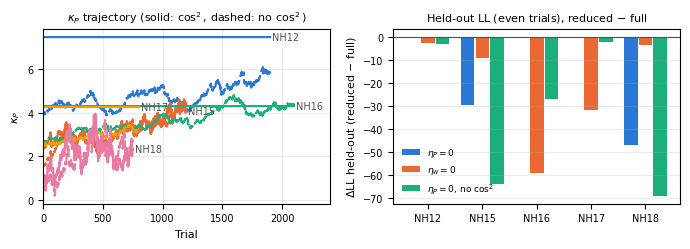

saved /Users/robaru/repos/active_inference/2026_IWAI/figures/fig_reviewer.pdf


In [11]:
S = MANUAL
PAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
ax = axes[0]
for i, s in enumerate(S):
    kc = Q2.loc[s, ('cos2', 'kappaP_traj')]
    kn = Q2.loc[s, ('nocos2', 'kappaP_traj')]
    ax.plot(kc, color=PAL[i], lw=1.6, label=s)
    ax.plot(kn, color=PAL[i], lw=1.6, ls='--')
    ax.text(len(kc) + 15, kc[-1], s, color='#52514e', fontsize=7, va='center')
ax.set_xlabel('Trial'); ax.set_ylabel(r'$\kappa_P$')
ax.set_title(r'$\kappa_P$ trajectory (solid: $\cos^2$, dashed: no $\cos^2$)', fontsize=8)
ax.set_xlim(0, 2400); ax.grid(alpha=0.25)
ax = axes[1]
x = np.arange(len(S))
ax.bar(x - 0.27, Q1_oddeven.loc[S, 'dLL etaP=0'], 0.25, color='#2a78d6', label=r'$\eta_P=0$')
ax.bar(x,        Q1_oddeven.loc[S, 'dLL etaw=0'], 0.25, color='#eb6834', label=r'$\eta_w=0$')
ax.bar(x + 0.27, Q2_heldout_nc.loc[S, 'dLL etaP=0 (no cos2)'], 0.25, color='#1baf7a', label=r'$\eta_P=0$, no $\cos^2$')
ax.axhline(0, color='#52514e', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(S, fontsize=7)
ax.set_ylabel(r'$\Delta$LL held-out (reduced $-$ full)')
ax.set_title('Held-out LL (even trials), reduced $-$ full', fontsize=8)
ax.legend(fontsize=6.5, frameon=False, loc='lower left'); ax.grid(alpha=0.25, axis='y')
for a in axes:
    a.tick_params(labelsize=7); a.xaxis.label.set_size(8); a.yaxis.label.set_size(8)
fig.tight_layout()
fig.savefig(OUT_FIG, format='pdf', bbox_inches='tight')
plt.show()
print('saved', OUT_FIG)


## 9 — Caveats

- **Bootstrap intervals for subjects with $\eta_P > 0$.** For a listener whose polar precision and hemifield weight both rise over training (NH15 in the paper), data simulated from the fitted trajectory can be explained almost equally well by a rise in $\kappa_P$ or a rise in $w$; the refits then attribute the improvement to $\eta_w$, and the bootstrap interval for $\eta_P$ does not contain the point estimate. Such intervals are flagged with $\dagger$ in Table 1 and not reported. The intervals are reliable as upper bounds for the subjects with $\eta_P \approx 0$. For subjects with $\eta_P > 0$ the evidence comes from the held-out comparison and from the stability of $\eta_P$ across fits on all, odd and first-half trials.
- **Listeners with near-uniform polar responses** (very low $\kappa_{P,0}$; NH18 in the paper): the likelihood is nearly flat in $\eta_w$, so $\eta_w$ is poorly identified and some reduced-model fits sit on a plateau; this is not an optimiser failure. Without the $\cos^2$ scaling the baseline fit for such a listener can return $w_0 \approx 1$ with a very small $\kappa_{P,0}$ ($w$ is unidentifiable when the polar distribution is near-uniform).
- **BADS is stochastic.** All fits use three starts with fixed seeds; refitting the full model on all trials reproduces the learning rates of the main notebook up to optimiser noise.
